### 여러가지 순환 신경망 사용
 - 영화리뷰데이터를 활용하여 여러가지 순환신경망을 사용해보고 더 나아가서 허깅페이스에서 제공하는 transformer기반의 모델을 사용해보기
 - SimpleRNN, LSTM, GRU 등 여러가지 모델 사용

In [ ]:
# 라이브러리 불러오기

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# 드라이브 마운트 진생

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# 작업 디렉토리 변경

%cd /content/drive/MyDrive/Colab Notebooks/딥러닝

In [ ]:
# 데이터 불러오기

naver_train_txt = pd.read_csv('./data/ratings_train.txt', delimiter = '\t')
naver_test_txt = pd.read_csv('./data/ratings_test.txt', delimiter = '\t')

In [ ]:
# 데이터프레임 확인

naver_train_txt.head()

In [ ]:
naver_test_txt.info()

In [ ]:
# 결측치 제거

naver_train_txt = naver_train_txt.dropna()

# naver_train_txt.dropna(inplace = True)
# dropna() : 결측치를 제거하는 기능

naver_test_txt = naver_test_txt.dropna()

In [ ]:
# 결측치 제거 확인

naver_train_txt.info()

In [ ]:
# 문제 데이터와 정답 데이터 분리

train_txt = naver_train_txt['document']
test_txt = naver_test_txt['document']
y_train = naver_train_txt['label']
y_test = naver_test_txt['label']

In [ ]:
train_txt

### 데이터 전처리
 - 텍스트 기반의 데이터를 사용할 때는 불용어처리, 오탈자 교정, 스페이스바 교정, 이모지 제거 등 전처리를 1차로 작업한 후 토큰화를 통해 내가 원하는 데이터를 분리하여 단어를 추출하고 임베딩 기법을 통해 의미를 잘 전달할 수 있도록 수치화 하는것이 정석.

In [ ]:
# 문장 데이터를 수치로 변환할 수 있도록 도와주는 도구 불러오기

from tensorflow.keras.layers import TextVectorization

In [ ]:
# 벡터화 도구 생성

vectorizer = TextVectorization(
    max_tokens = 5000,   # 사용할 최대 단어 토큰 수 제한 (빈도수 기반으로 하기 때문에 빈도가 많은 순으로 생성)
    output_mode = 'int',   # 빈도 기반으로 변환될 타입 설정
    standardize = 'lower_and_strip_punctuation',   # 대문자를 소문자로 변경, 마침표 제거 가능 (간단한 전처리)
    output_sequence_length = 10   # 문장의 길이를 제한 (부족하면 채우고 길면 자르는 기법)
)

In [ ]:
# 단어 학습 진행 (단어사전 생성)

vectorizer.adapt(train_txt)

In [ ]:
# 단어사전 갯수 확인

vectorizer.vocabulary_size()

In [ ]:
# 단어사전 확인 방법

vectorizer.get_vocabulary()

In [ ]:
# 단어사전 기반으로 수치화 진행(벡터화)

X_train_vec = vectorizer(train_txt)
X_test_vec = vectorizer(test_txt)

In [ ]:
X_train_vec[0]

# 데이터의 크기는 모두 길이가 10이다. => output_sequence_length = 10 으로 설정했기 때문에
# 모든 데이터의 길이가 10으로 지정되었다. (모델에 사용하려면 모든 데이터의 길이가 동일해야 한다.)
# 또한 수치가 모두 int인 이유는반환 타입을 int로 설정했기 때문

In [ ]:
# 데이터의 크기 확인

print(X_train_vec.shape)
print(X_test_vec.shape)

### 순환신경망 사용
 - 순환신경망을 사용할 때 데이터의 크기는 (샘플링의수, 순환횟수 (데이터의 길이), 특성의수)로 이루어져 있음
 - 만약에 순환신경망에 데이터를 넣을 때 (샘플링의 수, 순환회수(데이터의 길이))로만 이루어져 있을 경우 특성의 수를 1로 지정하여 사용할 수 있음

### 순환신경망 모델링

In [ ]:
# 도구 불러오기

from tensorflow.keras import Sequential
from tensorflow.keras.layers import InputLayer, Dense, SimpleRNN, LSTM

In [ ]:
# SimpleRNN을 사용
# 뼈대 쌓기

rnn_model = Sequential()


# 입력층 쌓기

rnn_model.add(InputLayer(shape = (10, 1)))   # 데이터의 길이가 10이기 때문


# RNN층 쌓기

rnn_model.add(SimpleRNN(units = 64, activation = 'tanh'))


# MLP층 쌓기

rnn_model.add(Dense(units = 64, activation = 'relu'))


# 출력층 쌓기

rnn_model.add(Dense(units = 1, activation = 'sigmoid'))

# 이진분류(긍정/부정) => units = 1 / activation = 'sigmoid'

In [ ]:
# 학습방법 및 평가방법 설정

rnn_model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [ ]:
# 학습진행

rnn_his = rnn_model.fit(
    X_train_vec, y_train,
    validation_split = 0.2,
    epochs = 20,
    batch_size = 64
)

In [ ]:
# 성능 시각화

plt.figure(figsize = (15, 5))
plt.plot(rnn_his.history['accuracy'], label = 'acc')
plt.plot(rnn_his.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### LSTM 모델 사용

In [ ]:
# LSTM 신경망 쌓기
# 뼈대 생성

lstm_model = Sequential()


# 입력층 쌓기

lstm_model.add(InputLayer(shape = (10, 1)))


# LSTM층 쌓기

lstm_model.add(LSTM(units = 64, activation = 'tanh'))


# MLP층 쌓기

lstm_model.add(Dense(units = 64, activation = 'relu'))


# 출력층 쌓기

lstm_model.add(Dense(units = 1, activation = 'sigmoid'))

In [ ]:
# 학습방법 및 평가방법 설정

lstm_model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [ ]:
# 학습진행

lstm_model.fit(
    X_train_vec, y_train,
    validation_split = 0.2,
    epochs = 20,
    batch_size = 64
)

In [ ]:
# 성능 시각화 진행

plt.figure(figsize = (15, 5))
plt.plot(lstm_model.history.history['accuracy'], label = 'acc')
plt.plot(lstm_model.history.history['val_accuracy'], label = 'val_acc')
plt.legend()
plt.show()

### 결과 확인
 - SimpleRNN보다는 LSTM모델이 성능이 조금 더 높은것을 확인.
 - 하지만 데이터 전처리를 하지 않았기 때문에 특정 이상의 성능을 기대하기 어렵다.
 - 결국은 데이터 전처리의 유무가 결과에 영향을 크게 준다는 것을 알 수 있다.

In [ ]:
# 조금이라도 성능 개선을 위해 Embedding 층 쌓아보기
# 임베딩 레이어

from tensorflow.keras.layers import Embedding

In [ ]:
# LSTM모델과 Embedding레이어를 활용한 학습 진행

emb_model = Sequential()


# 임베딩 레이어 추가

emb_model.add(Embedding(5000, 50))

# 단어사전의 수가 5000개이기 때문에 5000으로 설정
# 벡터의 크기를 50으로 지정한 것은 정답이 아님 => 임의의 개수로 지정하되 너무 크거나 작지 않도록 설정

# LSTM층 쌓기

emb_model.add(LSTM(units = 64, activation = 'tanh'))


# MLP층 쌓기

emb_model.add(Dense(units = 64, activation = 'relu'))


# 출력층 쌓기

emb_model.add(Dense(units = 1, activation = 'sigmoid'))

In [ ]:
# 학습방법 설정

emb_model.compile(
    loss = 'binary_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [ ]:
# 학습진행

emb_his = emb_model.fit(
    X_train_vec, y_train,
    validation_split = 0.2,
    epochs = 20,
    batch_size = 64
)

### 결론 정리
 - 텍스트 데이터를 다룰 때에는 전처리 작업이 결과에 영향을 많이 미치는것을 확인할 수 있었다.
 - 결국 데이터를 다룰 때 전처리 작업의 유무에 따라 결과에 영향을 많이 미치기 때문에 전처리 작업도 매우 중요하다.

### GRU 모델
 - LSTM의 과도한 연산으로 인한 학습속도를 개선하기 위해 나온 모델
 - 성능적인 측면을 개선하기 위해 나온 모델은 아니기 때문에 성능적인 측면에서 개선이 되었다고는 하기 어려움

In [ ]:
# 도구 불러오기

from tensorflow.keras.layers import GRU


# 사용방법
# LSTM자리에 GRU만 바꿔 들어가면 된다.

### 허깅페이스(Hugging_face)
 - 인공지능 관련 데이터셋, 모델, 테스팅 공간 등을 공유하는 거대 커뮤니티 웹서비스.
 - 여러가지 모델을 공유하여 사용할 수 있기 때문에 내가 다른사람이 학습시켜놓은 모델을 가져다가 사용이 가능하다.
 - 내가 학습시킨 모델도 업로드하여 다른사람이 사용할 수 있도록 설정 가능.

### 시퀀스-투-시퀀스(Sequence-toSequence)
 - 번역기에서 대표적으로 사용되는 모델
 - 인코더와 디코더라는 두개의 모듈로 구성
 - 인코더 : 입력된 문장의 모든 단어를 학습하여 정보를 압축하여 의미를 해석하는 모델 (의미를 해석하는 모델)
 - 디코더 : 데이터를 받아서 번역된 단어를 순차적으로 출력하는 모델 (출력하는 모델)

### Transformer
  - 필요한 것은 주의 집중(Attention is All You Need) 논문으로 2017년 발표
  - 순환과 컨볼루션을 완전히 배제하고 오로지 Attention 메커니즘에만 기반을 둔 새롭고 단순한 신경망 아키텍처

  - 인코더와 디코더로 구성
  - 인코더
    - 트랜스포머는 하이퍼파라미터인 num_layers 개수의 인코더 층을 쌓음
    - 하나의 인코더 층은 크게 셀프 어텐션과 피드 포워드 신경망의 2개의 서브층(sublayer)으로 구성
      - Multi-head Self-Attention : 셀프 어텐션을 병렬적으로 사용
      - Position-wise FFNN : 일반적인 피드 포워드 신경망
    - 인코딩의 출력은 디코더로 전달

  - 디코더
    - num_layers 개수의 디코더 층을 쌓음  
    - 인코더에서 보낸 출력을 디코더 층의 연산에 사용
    - 디코더는 3개 층으로 구성
      - Masked Multi-head Self-Attention (Self Attention과 Look-ahead mask): 현재 시점의 예측에서 현재 시점보다 미래에 있는 단어들을 참고하지 못하도록 룩-어헤드 마스크(look-ahead mask)를 사용
        - 트랜스포머는 문장 행렬로 입력을 한 번에 받으므로 현재 시점의 단어를 예측하고자 할 때, 입력 문장 행렬로부터 미래 시점의 단어까지도 참고할 수 있는 현상이 발생
      - Multi-head Self-Attention (Encoder-Decoder Attention) : 멀티 헤드 어텐션을 수행
      - Position-wise FFNN

<center>  
<img src="https://arome1004.cafe24.com/images/deeplearning/transformer_attention_overview.png" width=60%>   
</center>    




## Transformer 구조

> **Positional Encoding (위치 인코딩)**
> - Self-Attention 기반 모델은 입력 순서를 순차적으로 처리하지 못 함
> - 이에 대해 **<U>토큰 간 순서 정보**</U>를 알려주기 위함 (한 문장을 병렬로 처리하면서도 각 단어의 위치를 인지하게 됨)

> **Encoder Self-Attention**
> - 인코더는 **<U>입력 문장의 모든 단어 간의 관계**</U>를 계산하여, 문장 전체에서 중요한 정보를 파악

> **Add & Norm**
> - 출력에 원래 입력을 **<U>더하고, 값을 정규화**</U>하여 안정된 학습을 도움
> - ResNet - Skip Connection 개념 차용

> **Feed Forward**
> - 활성화 함수(ReLU)를 사용해 입력을 처리해서, 비선형성을 통해 모델이 더 복잡한 패턴을 학습할 수 있게 만드는 **<U>완전 연결 신경망**</U> (쉽게 MLP 떠올리면 됨)

> **Masked Decoder Self-Attention**
> - 디코더가 예측할 때 미래 단어를 **<U>참조하지 못하게 막아**</U>, 이전 단어들만을 사용해 순차적으로 예측

> **Encoder-Decoder Self-Attention**
> - Seq2Seq Attention (Bahdanau/Luong)에서 발전된 형태
> - **<U>디코더가 인코더의 출력을 참조**</U>하여,  입력 문장과의 관계를 기반으로 더 정확한 출력을 생성

In [ ]:
# transformer 라이브러리 설치

!pip install transformers[torch]==4.42   # 4.42 버전 사용

# 세션 다시시작 뜨면 다시시작 눌러주기 안그러면 사용이 안됨

### 문장번역 모델 사용(Translation)

In [ ]:
from transformers import pipeline

In [ ]:
# 번역 모델 사용

translator = pipeline(
    task = 'translation',   # 작업단위 설정 (목적 설정)
    model = 'Helsinki-NLP/opus-mt-ko-en',   # 원하는 모델 불러서 지정 (모델 명)
    device = 0
)

In [ ]:
# 번역하기

text = '나는 오늘 집에 가서 쉬고 싶어요.'
translator(text)

### Transformer 종류
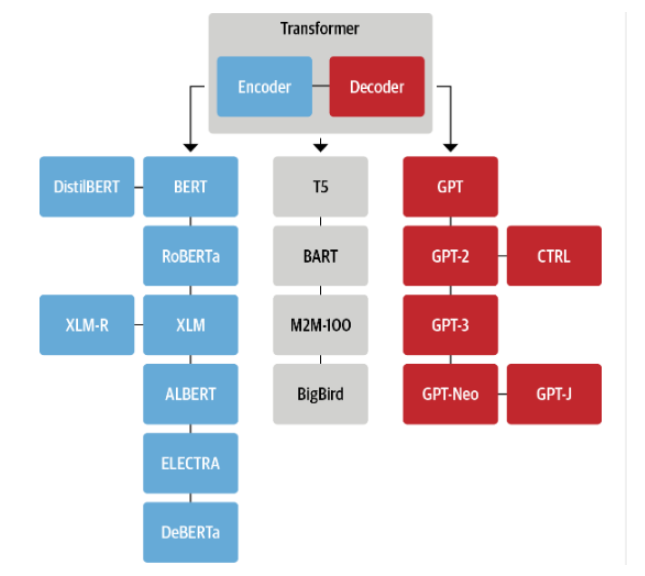

- 넓은 관점에서 트랜스포머 모델은 세 가지로 범주화 할 수 있음

> BERT 계열
> - Transformer 모델의 Encoder만 활용
> - 입력 전체를 한 번에 보고, 양방향으로 학습
> - 대표 모델 : BERT, ELECTRA 등
> - 주 사용처 : 문장 분류, 개체명 인식, 문장 유사도 등 전체 문장에 대한 이해를 요구하는 작업
>     - 빠른 추론과 가벼운 배포가 장점, 분류/검색/추천/임베딩 등 읽기 중심의 task에 많이 쓰임

> Seq2Seq 계열
> - Sequence-to-Sequence(Encoding → Decoding) 구조
> - 다양한 생성, 이해 작업에 강점을 가짐
> - 대표 모델 : T5, BART 등
> - 주 사용처 : 제로샷 분류, 요약/번역/재작성 등
>     - 다수 task(요약, 번역, 생성 등)을 하나의 모델로 운영 할 때 자주 사용

> GPT 계열
> - Transformer 모델의 Decoder만 활용
> - 입력을 순차적으로 처리하며 다음 토큰 예측(순방향)
> - 대표 모델 : GPT, GPT-2, CTRL, GPT-3, GPT-4 등
> - 주 사용처 : 텍스트 생성, 대화형 에이전트 등
>     - 창의적 생성이 장점, 프롬프트 엔지니어링이 중요할 때 선호

In [ ]:
# 한국어 분류 모델 사용(Ko Electra) Pipeline 로드

classifier = pipeline(
    task = 'sentiment-analysis',   # 감정분석
    model = 'daekeun-ml/koelectra-small-v3-nsmc',   # 허깅페이스에서 자료 가져오기
    device = 0
)

In [ ]:
# 감정 분석 진행
# 0 => 부정 / 1 => 긍정

test_text = '넌 정말 좋은 사람이야.'
classifier(test_text)

In [ ]:
# test